# **한글사용 처리**


---

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt   #시각화를 위한 라이브러리

# 레티나 디스플레이를 지원하도록 해서 한글이 흐릿하게 보이는 현상 개선
%config InlineBackend.figure_format = 'retina'

#한글 나눔 폰트 사용설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

 #해당 폰트를 기본 폰트가 되도록 설정
import matplotlib.font_manager as fm
fontpath = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
font = fm.FontProperties(fname=fontpath, size=9)
plt.rc('font', family='NanumBarunGothic')

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 16 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

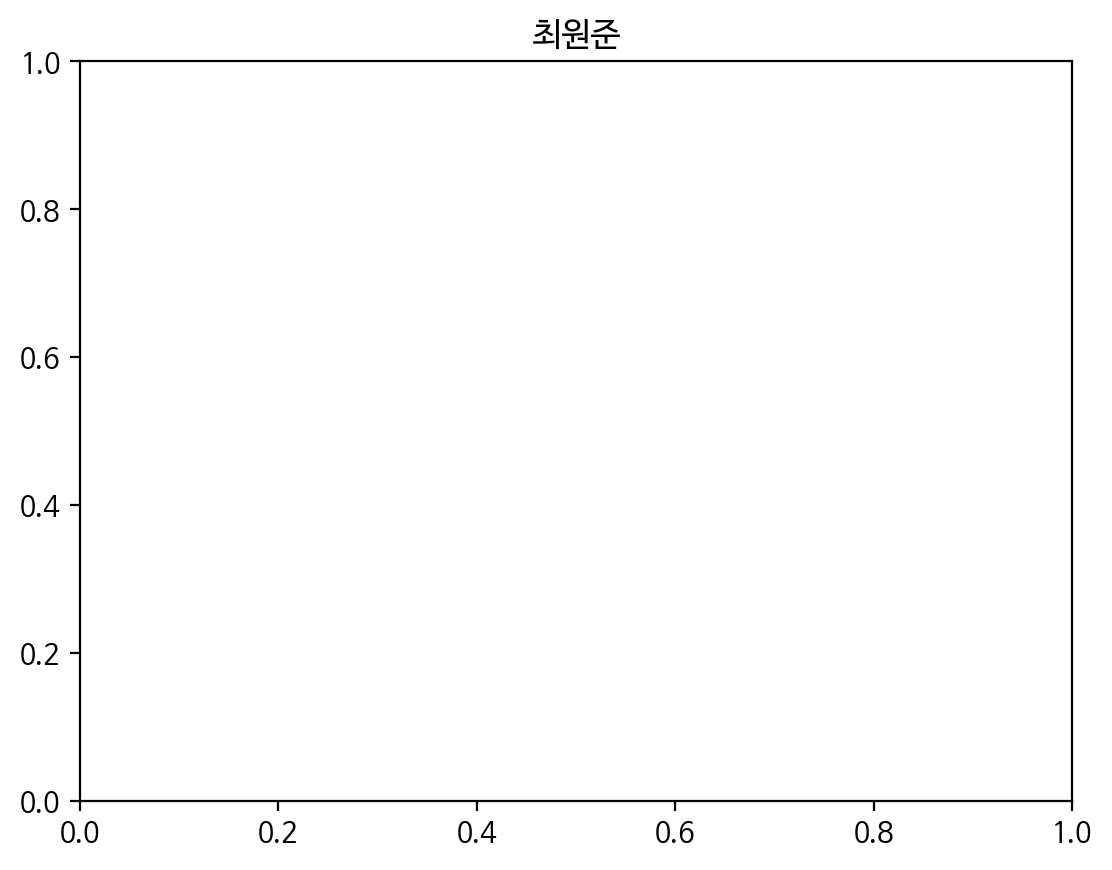

In [ ]:
plt.title('최원준')
plt.show()

# 해결문제


---
기상개황 자료를 이용하여 월별 불쾌지수를 계산하고 불쾌지수가 높음이상인 월을 구하시오.


https://kosis.kr/statHtml/statHtml.do?orgId=735&tblId=DT_A1040&vw_cd=MT_ZTITLE&list_id=215_215A_735_73503_A&seqNo=&lang_mode=ko&language=kor&obj_var_id=&itm_id=&conn_path=MT_ZTITLE

+ 불쾌지수 공식

  + DI = 0.81 \* Ta + 0.01 \* RH * (0.99 \* Ta - 14.3) + 46.3

  >+ DI: 불쾌지수
  >+Ta: 건구온도(평균기온)
  >+RH: 상대습도(평균상대습도)

+ 불쾌지수 단계

  + 매우높음: 80이상
  + 높음: 75이상 80미만
  + 보통: 68이상 75미만
  + 낮음: 68미만

In [ ]:
#pandas 라이브러리 추가
import pandas as pd

In [ ]:
#코랩에서 사용할 파일을 업로드하기
from google.colab import files
myfile = files.upload()

Saving 기상개황.csv to 기상개황.csv


In [ ]:
#cp949 방식으로 인코딩된 기상개황.csv 파일을 불러와서
#df라는 이름의 데이터 프레임에 저장하기
df=pd.read_csv('기상개황.csv',encoding='cp949')
df

,월별(1),평균기온 (℃),평균최고기온 (℃),최고극값기온 (℃),평균최저기온 (℃),최저극값기온 (℃),강수량 (㎜),평균상대습도 (%),최소상대습도 (%),평균 해면기압 (hPa),이슬점 온도 (℃),평균운량 (1/10),일조시간 (hr),최심신적설 (㎝),평균풍속바람 (m/s),최대풍속바람 (m/s),최대순간풍속 (m/s)
0,연간,14.2,19.1,37.0,10.1,-12.0,1507.3,67,1,1016.3,7.3,4.8,2298.6,-,1.6,12.6,23.5
1,1월,0.3,4.9,13.8,-3.6,-12.0,26.7,46,3,1022.6,-11.0,3.8,208.9,-,1.7,6.4,12.2
2,2월,2.6,7.8,14.6,-2.2,-10.2,32.6,38,1,1022.2,-12.1,3.7,201.4,-,1.8,7.3,12.4
3,3월,9.1,14.8,23.2,4.1,-1.9,186.0,67,13,1019.7,2.4,4.2,205.7,-,1.9,9.0,17.1
4,4월,14.4,20.2,27.3,9.5,1.2,119.3,67,13,1015.7,7.1,4.7,231.3,-,1.8,7.6,13.4
5,5월,18.1,23.4,29.0,13.8,8.3,145.0,76,13,1011.9,13.1,6.1,188.6,-,1.8,6.5,11.7
6,6월,21.7,26.8,34.7,17.9,13.9,194.8,80,33,1008.2,17.5,6.1,186.9,-,1.6,6.4,10.7
7,7월,27.1,31.8,36.4,23.3,17.8,146.0,84,45,1008.6,23.9,4.7,166.4,-,1.5,6.4,10.5
8,8월,27.5,32.2,37.0,24.1,19.8,243.7,83,48,1007.6,24.1,5.6,192.3,-,1.7,8.5,17.4
9,9월,21.3,25.1,30.2,18.1,12.9,216.4,82,37,1012.9,17.7,7.1,122.4,-,1.3,5.3,10.4


In [ ]:
#수치 계산을 위한 numpy 라이브러리 불러오기
import numpy as np

In [ ]:
#방법1: '평균기온 (℃) > 20 -> '더움', '평균기온 (℃)' > 10 -> '쾌적' 그 외 -> '추움'
np.where(df['평균기온 (℃)']>20,'더움',np.where(df['평균기온 (℃)']>10,'쾌적','추움'))

array(['쾌적', '추움', '추움', '추움', '쾌적', '쾌적', '더움', '더움', '더움', '더움', '쾌적',
       '쾌적', '추움'], dtype='<U2')

In [ ]:
#방법2: '평균기온 (℃) > 20 -> '더움', '평균기온 (℃)' > 10 -> '쾌적' 그 외 -> '추움'
['더움' if item>20 else '쾌적' if item>10 else '추움' for item in df['평균기온 (℃)']]

['쾌적', '추움', '추움', '추움', '쾌적', '쾌적', '더움', '더움', '더움', '더움', '쾌적', '쾌적', '추움']

In [ ]:
#열 확인
df.columns

Index(['월별(1)', '평균기온 (℃)', '평균최고기온 (℃)', '최고극값기온 (℃)', '평균최저기온 (℃)',
       '최저극값기온 (℃)', '강수량 (㎜)', '평균상대습도 (%)', '최소상대습도 (%)', '평균 해면기압 (hPa)',
       '이슬점 온도 (℃)', '평균운량 (1/10)', '일조시간 (hr)', '최심신적설 (㎝)', '평균풍속바람 (m/s)',
       '최대풍속바람 (m/s)', '최대순간풍속 (m/s)'],
      dtype='object')

In [ ]:
#필요한 자료 추출
df2 = df[['월별(1)','평균기온 (℃)','평균상대습도 (%)']]
df2

,월별(1),평균기온 (℃),평균상대습도 (%)
0,연간,14.2,67
1,1월,0.3,46
2,2월,2.6,38
3,3월,9.1,67
4,4월,14.4,67
5,5월,18.1,76
6,6월,21.7,80
7,7월,27.1,84
8,8월,27.5,83
9,9월,21.3,82


In [ ]:
# 열명변경
df2.columns=['월별','평균기온','평균상대습도']
df2

,월별,평균기온,평균상대습도
0,연간,14.2,67
1,1월,0.3,46
2,2월,2.6,38
3,3월,9.1,67
4,4월,14.4,67
5,5월,18.1,76
6,6월,21.7,80
7,7월,27.1,84
8,8월,27.5,83
9,9월,21.3,82


In [ ]:
#경고 메시지 무시
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# 불쾌지수 계산
Ta = df2['평균기온']
RH = df2['평균상대습도']
df2['불쾌지수']=0.81 * Ta + 0.01 * RH * (0.99 * Ta - 14.3) + 46.3
df2.head()

,월별,평균기온,평균상대습도,불쾌지수
0,연간,14.2,67,57.63986
1,1월,0.3,46,40.10162
2,2월,2.6,38,43.95012
3,3월,9.1,67,50.12603
4,4월,14.4,67,57.93452


불쾌지수 단계






*   매우높음: 80이상
*   높음: 75이상 80미만
*   보통: 68이상 75미만
*   낮음: 68미만





In [ ]:
# 불쾌지수가 높음이상(75이상)
df2['단계']=np.where(df2['불쾌지수']>=80,'매우높음',np.where(df2['불쾌지수']>=75,'높음', np.where(df2['불쾌지수']>=68,'보통','낮음')))
df2

,월별,평균기온,평균상대습도,불쾌지수,단계
0,연간,14.2,67,57.63986,낮음
1,1월,0.3,46,40.10162,낮음
2,2월,2.6,38,43.95012,낮음
3,3월,9.1,67,50.12603,낮음
4,4월,14.4,67,57.93452,낮음
5,5월,18.1,76,63.71144,낮음
6,6월,21.7,80,69.62340,보통
7,7월,27.1,84,78.77536,높음
8,8월,27.5,83,79.30275,높음
9,9월,21.3,82,69.11834,보통


In [ ]:
#'단계'가 '매우높음', '높음' 에 해당하는 '월별'에 있는 데이터를 리스트로 출력 - [방법1]
list(df2[df2['단계'].isin(['매우높음','높음'])]['월별'])

['7월', '8월']

In [ ]:
#'단계'가 '매우높음', '높음' 에 해당하는 '월별'에 있는 데이터를 리스트로 출력 - [방법2]
list(df2[(df2['단계']=='매우높음')|(df2['단계']=='높음')]['월별'])

['7월', '8월']

In [ ]:
#'불쾌지수' >= 75 인 '월별'에 있는 데이터를 리스트로 출력
list(df2[df2['불쾌지수']>=75]['월별'])

['7월', '8월']

In [ ]:
#행인덱스 변경
df2 = df2.set_index('월별')
df2

,평균기온,평균상대습도,불쾌지수,단계
월별,,,,
연간,14.2,67,57.63986,낮음
1월,0.3,46,40.10162,낮음
2월,2.6,38,43.95012,낮음
3월,9.1,67,50.12603,낮음
4월,14.4,67,57.93452,낮음
5월,18.1,76,63.71144,낮음
6월,21.7,80,69.62340,보통
7월,27.1,84,78.77536,높음
8월,27.5,83,79.30275,높음


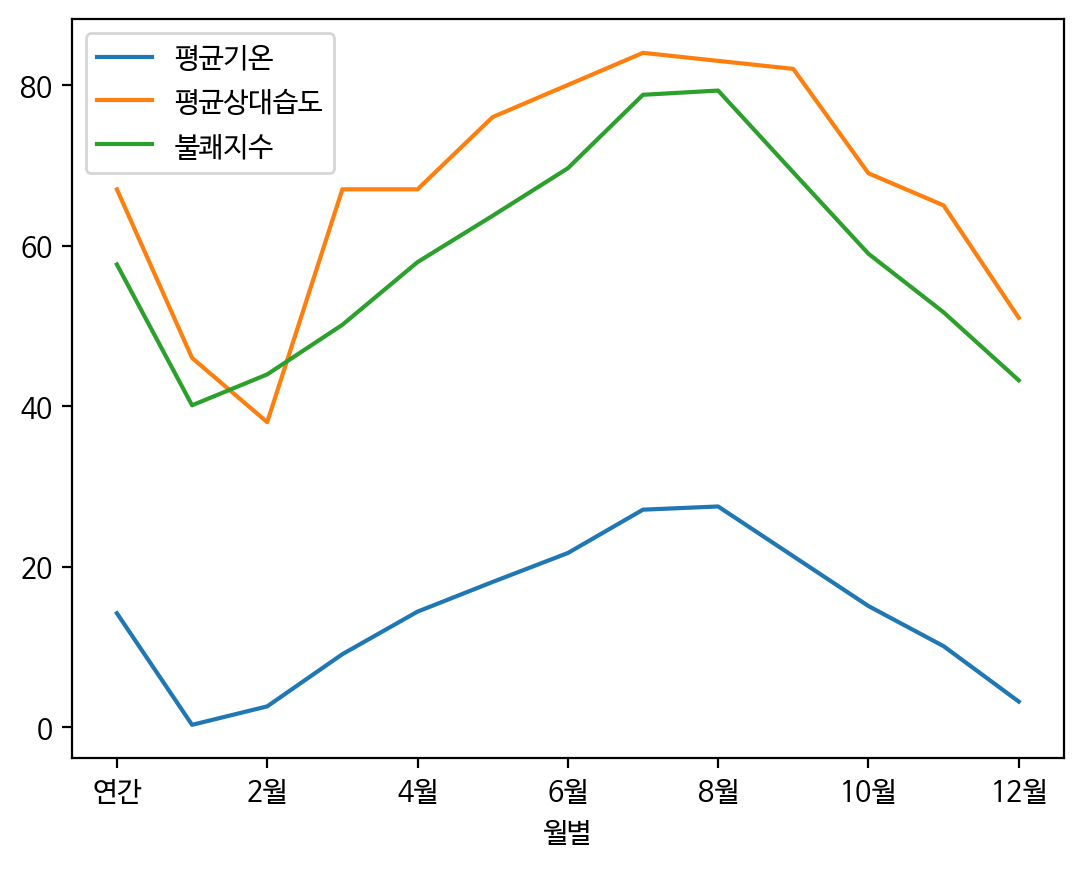

In [32]:
#그래프 그리기1
df2.plot()
plt.show()

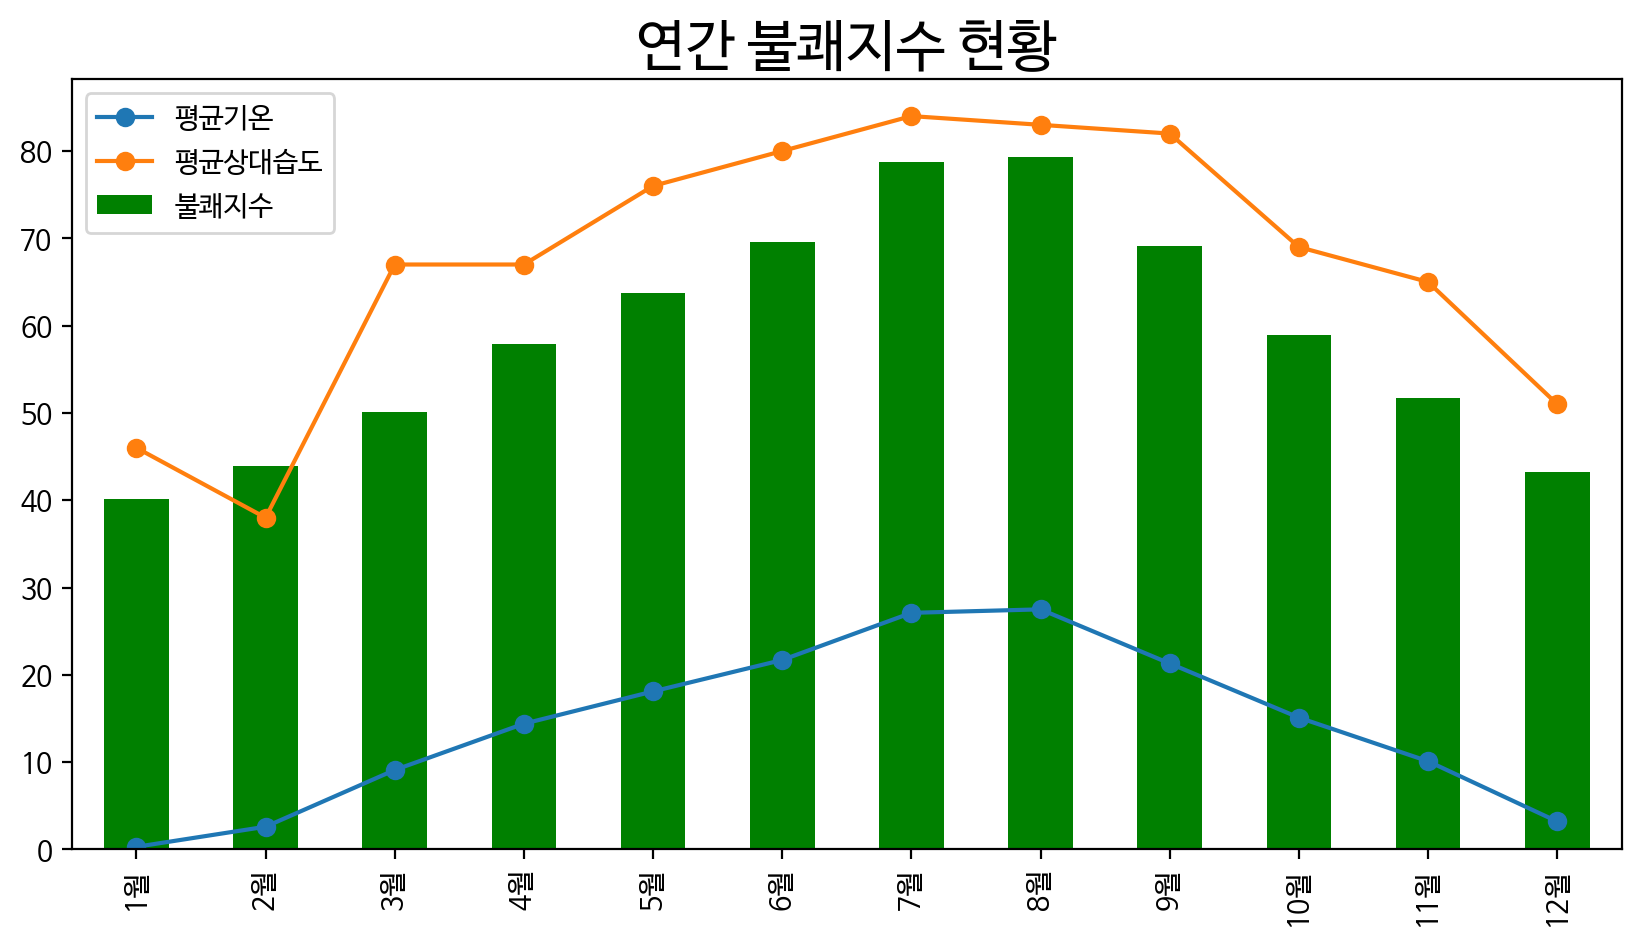

In [50]:
#그래프 그리기2
df2.iloc[1:,:][['평균기온','평균상대습도']].plot(marker='o',figsize=(10,5))
df2.iloc[1:,:]['불쾌지수'].plot(kind='bar',color='g',label='불쾌지수')
plt.legend(loc='upper left')
plt.title('연간 불쾌지수 현황',fontsize=20)
plt.xlabel('')
plt.show()

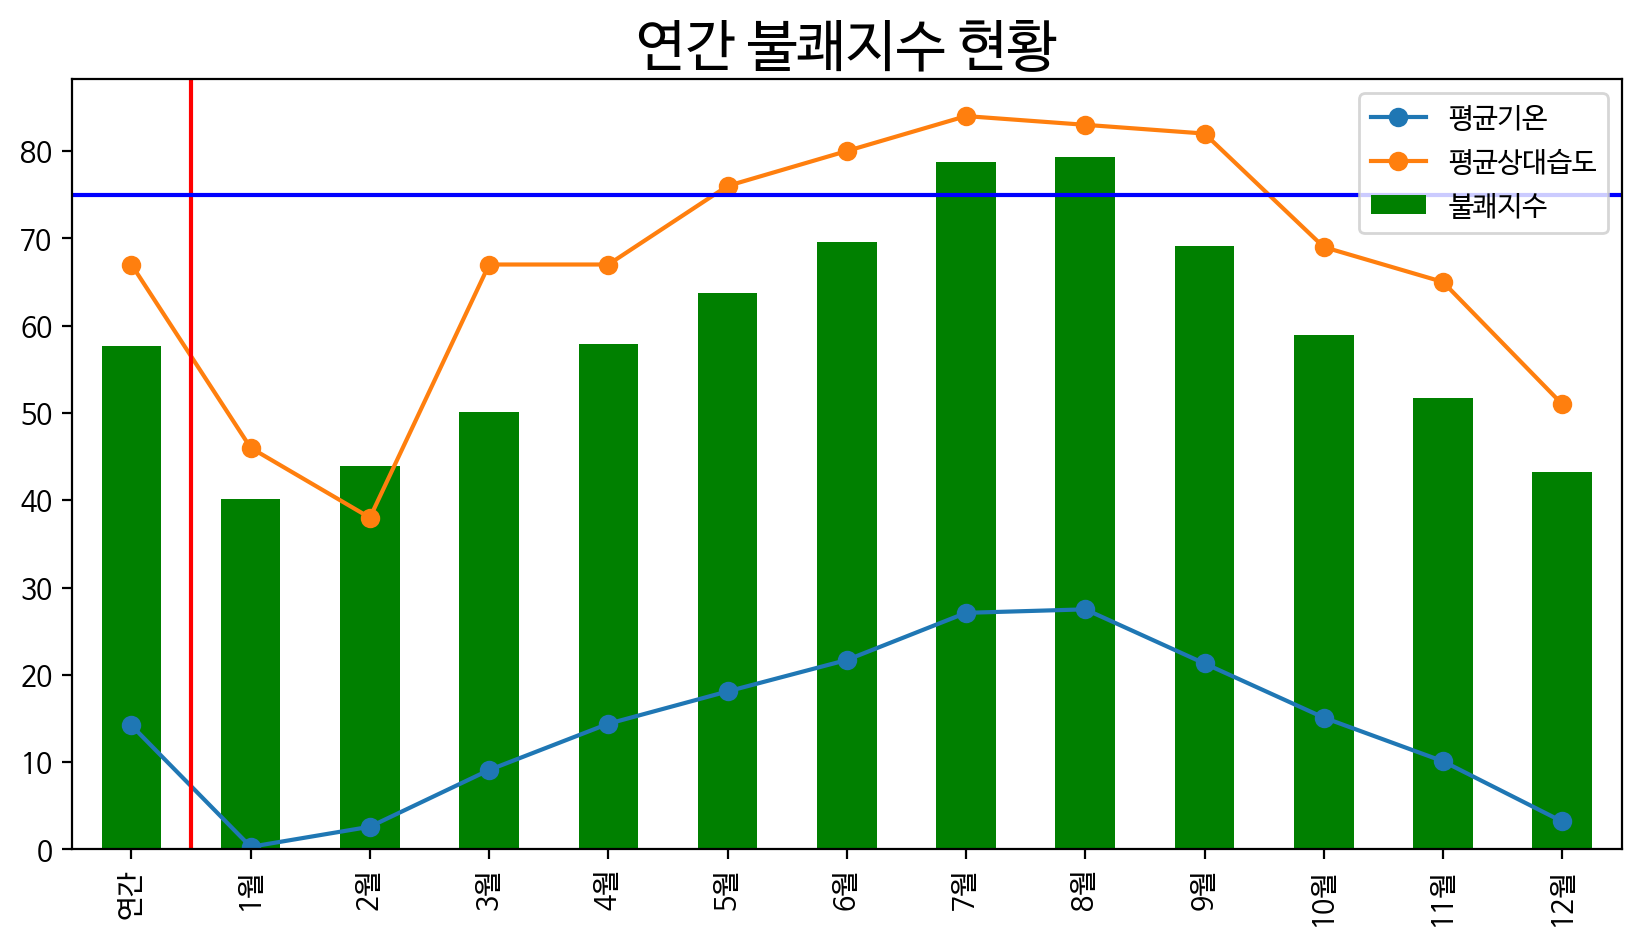

In [52]:
#그래프 그리기3
df2[['평균기온', '평균상대습도']].plot(marker='o', figsize=(10, 5))
df2['불쾌지수'].plot(kind='bar', color='g', label='불쾌지수')
plt.legend(loc='upper right')
plt.title('연간 불쾌지수 현황', fontsize=20)
plt.axvline(x=0.5,color='r')
plt.axhline(y=75,color='b')
plt.xlabel('')
plt.show()